# Task 2 – Implementación "Frozen Lake" en Python

Resolvemos el entorno **Frozen Lake** donde un agente debe cruzar un lago congelado evitando agujeros.  
El hielo es resbaladizo: al tomar una acción, hay **1/3** de probabilidad de ir a donde se desea y **1/3** para cada dirección perpendicular.

**Restricciones:** Solo se usan `numpy`, `pandas` y `matplotlib`. No se usa `gym`, `sklearn`, `pytorch` ni `tensorflow`.

## Importar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

---
## Task 2.1 – Modelado del MDP

Implementamos la clase `FrozenLakeMDP` desde cero:
- **Estados:** 0 a 15 (grid 4×4)
- **Acciones:** Norte (N), Sur (S), Este (E), Oeste (W)
- **Función de transición** $T(s, a, s')$: captura la estocasticidad del hielo
- **Función de recompensa** $R(s, a, s')$

### Mapa del lago

```
S  F  F  F       (0   1   2   3)
F  H  F  H       (4   5   6   7)
F  F  F  H       (8   9  10  11)
H  F  F  G       (12  13  14  15)
```

- **S** = Start (inicio)
- **G** = Goal (meta, recompensa +1)
- **H** = Hole (agujero, recompensa 0, fin del juego)
- **F** = Frozen (camino seguro)

In [2]:
class FrozenLakeMDP:
    """
    Modelado del MDP para el entorno Frozen Lake 4x4.
    
    El hielo es resbaladizo: al elegir una acción, hay 1/3 de probabilidad
    de moverse en la dirección deseada y 1/3 para cada dirección perpendicular.
    """

    # Mapa estándar de Frozen Lake 4x4
    DEFAULT_MAP = [
        "SFFF",
        "FHFH",
        "FFFH",
        "HFFG",
    ]

    # Acciones: 0=Norte, 1=Sur, 2=Este, 3=Oeste
    ACTIONS = {0: "N", 1: "S", 2: "E", 3: "W"}
    ACTION_NAMES = ["Norte", "Sur", "Este", "Oeste"]
    N_ACTIONS = 4

    # Desplazamientos (fila, columna) para cada acción
    # Norte = fila-1, Sur = fila+1, Este = col+1, Oeste = col-1
    ACTION_DELTAS = {
        0: (-1, 0),   # Norte
        1: (1, 0),    # Sur
        2: (0, 1),    # Este
        3: (0, -1),   # Oeste
    }

    # Direcciones perpendiculares para cada acción
    # Si la acción es N o S, los perpendiculares son E y W
    # Si la acción es E o W, los perpendiculares son N y S
    PERPENDICULAR = {
        0: [2, 3],  # Norte -> Este, Oeste
        1: [2, 3],  # Sur   -> Este, Oeste
        2: [0, 1],  # Este  -> Norte, Sur
        3: [0, 1],  # Oeste -> Norte, Sur
    }

    def __init__(self, lake_map=None):
        """
        Inicializa el MDP de Frozen Lake.
        
        Parameters
        ----------
        lake_map : list of str, optional
            Mapa del lago. Por defecto usa el mapa estándar 4x4.
        """
        self.lake_map = lake_map if lake_map is not None else self.DEFAULT_MAP
        self.n_rows = len(self.lake_map)
        self.n_cols = len(self.lake_map[0])
        self.n_states = self.n_rows * self.n_cols

        # Identificar estados terminales y tipo de celda
        self.cell_type = {}   # state -> 'S', 'F', 'H', 'G'
        self.terminal_states = set()
        self.hole_states = set()
        self.goal_states = set()

        for r in range(self.n_rows):
            for c in range(self.n_cols):
                s = self._rc_to_state(r, c)
                cell = self.lake_map[r][c]
                self.cell_type[s] = cell
                if cell == "H":
                    self.terminal_states.add(s)
                    self.hole_states.add(s)
                elif cell == "G":
                    self.terminal_states.add(s)
                    self.goal_states.add(s)

        # Pre-computar la tabla de transiciones T(s, a) -> lista de (prob, s')
        self.transitions = self._build_transitions()

    # ------------------------------------------------------------------ #
    #  Utilidades de conversión estado <-> (fila, columna)
    # ------------------------------------------------------------------ #
    def _rc_to_state(self, r, c):
        """Convierte (fila, columna) a un índice de estado."""
        return r * self.n_cols + c

    def _state_to_rc(self, s):
        """Convierte un índice de estado a (fila, columna)."""
        return divmod(s, self.n_cols)

    # ------------------------------------------------------------------ #
    #  Movimiento con comprobación de límites
    # ------------------------------------------------------------------ #
    def _move(self, state, action):
        """
        Calcula el estado resultante al ejecutar `action` desde `state`.
        Si el movimiento sale del grid, el agente se queda en su lugar.
        
        Parameters
        ----------
        state : int
        action : int  (0=N, 1=S, 2=E, 3=W)
        
        Returns
        -------
        int : estado resultante
        """
        r, c = self._state_to_rc(state)
        dr, dc = self.ACTION_DELTAS[action]
        new_r, new_c = r + dr, c + dc

        # verificar límites del grid
        if 0 <= new_r < self.n_rows and 0 <= new_c < self.n_cols:
            return self._rc_to_state(new_r, new_c)
        else:
            return state  # se queda en el mismo lugar

    # ------------------------------------------------------------------ #
    #  Construcción de la tabla de transiciones T(s, a)
    # ------------------------------------------------------------------ #
    def _build_transitions(self):
        """
        Construye la función de transición T(s, a) -> [(prob, s'), ...].
        
        Dinámica estocástica del hielo:
        - 1/3 de probabilidad de moverse en la dirección deseada
        - 1/3 de moverse en cada dirección perpendicular
        
        Los estados terminales (H y G) son absorbentes: cualquier acción
        mantiene al agente en el mismo estado con probabilidad 1.
        
        Returns
        -------
        dict : {(state, action): [(prob, next_state), ...]}
        """
        transitions = {}

        for s in range(self.n_states):
            for a in range(self.N_ACTIONS):
                if s in self.terminal_states:
                    # Estado terminal: absorbente
                    transitions[(s, a)] = [(1.0, s)]
                else:
                    outcomes = {}  # next_state -> probabilidad acumulada
                    # Dirección deseada (1/3)
                    s_intended = self._move(s, a)
                    outcomes[s_intended] = outcomes.get(s_intended, 0.0) + 1/3

                    # Direcciones perpendiculares (1/3 cada una)
                    for perp_a in self.PERPENDICULAR[a]:
                        s_perp = self._move(s, perp_a)
                        outcomes[s_perp] = outcomes.get(s_perp, 0.0) + 1/3

                    transitions[(s, a)] = [(p, ns) for ns, p in outcomes.items()]

        return transitions

    # ------------------------------------------------------------------ #
    #  Función de transición T(s, a, s')
    # ------------------------------------------------------------------ #
    def T(self, s, a, s_prime):
        """
        Probabilidad de transición T(s, a, s').
        
        Parameters
        ----------
        s : int       – estado actual
        a : int       – acción tomada
        s_prime : int – estado siguiente
        
        Returns
        -------
        float : probabilidad de llegar a s' desde s ejecutando a
        """
        for prob, ns in self.transitions[(s, a)]:
            if ns == s_prime:
                return prob
        return 0.0

    # ------------------------------------------------------------------ #
    #  Función de recompensa R(s, a, s')
    # ------------------------------------------------------------------ #
    def R(self, s, a, s_prime):
        """
        Recompensa al transitar de s a s' ejecutando a.
        
        - Llegar al Goal (G): +1
        - Cualquier otro caso: 0
        
        Parameters
        ----------
        s : int       – estado actual
        a : int       – acción
        s_prime : int – estado siguiente
        
        Returns
        -------
        float : recompensa
        """
        if s_prime in self.goal_states:
            return 1.0
        return 0.0

    # ------------------------------------------------------------------ #
    #  Representación del mapa
    # ------------------------------------------------------------------ #
    def print_map(self):
        """Imprime el mapa del lago con los índices de estado."""
        print("Mapa del Frozen Lake:")
        print("-" * 25)
        for r in range(self.n_rows):
            row_cells = []
            for c in range(self.n_cols):
                s = self._rc_to_state(r, c)
                cell = self.lake_map[r][c]
                row_cells.append(f"{cell}({s:2d})")
            print("  ".join(row_cells))
        print("-" * 25)
        print("S=Start, F=Frozen, H=Hole, G=Goal")

### Instanciar el MDP y visualizar el mapa

In [3]:
mdp = FrozenLakeMDP()
mdp.print_map()

Mapa del Frozen Lake:
-------------------------
S( 0)  F( 1)  F( 2)  F( 3)
F( 4)  H( 5)  F( 6)  H( 7)
F( 8)  F( 9)  F(10)  H(11)
H(12)  F(13)  F(14)  G(15)
-------------------------
S=Start, F=Frozen, H=Hole, G=Goal


### Verificar la función de transición

Comprobamos que las probabilidades de transición sumen 1 para cada par $(s, a)$ y mostramos algunos ejemplos.

In [4]:
# Verificar que las probabilidades suman 1 para cada (s, a)
print("Verificación de probabilidades de transición:")
all_ok = True
for s in range(mdp.n_states):
    for a in range(mdp.N_ACTIONS):
        total = sum(p for p, _ in mdp.transitions[(s, a)])
        if not np.isclose(total, 1.0):
            print(f"  ERROR: T(s={s}, a={mdp.ACTIONS[a]}) suma = {total:.4f}")
            all_ok = False
if all_ok:
    print("  ✓ Todas las probabilidades suman 1.0 correctamente.")

print("\nEjemplos de transiciones:")
# Estado 0 (Start), acción Norte: debería quedarse o moverse lateralmente
print(f"\nDesde estado 0 (S), acción Norte:")
for prob, ns in mdp.transitions[(0, 0)]:
    r, c = mdp._state_to_rc(ns)
    print(f"  -> estado {ns} ({mdp.cell_type[ns]}) en ({r},{c}) con prob {prob:.4f}")

# Estado 6 (F), acción Este
print(f"\nDesde estado 6 (F), acción Este:")
for prob, ns in mdp.transitions[(6, 2)]:
    r, c = mdp._state_to_rc(ns)
    print(f"  -> estado {ns} ({mdp.cell_type[ns]}) en ({r},{c}) con prob {prob:.4f}")

# Estado 5 (H - terminal), cualquier acción
print(f"\nDesde estado 5 (H - terminal), acción Sur:")
for prob, ns in mdp.transitions[(5, 1)]:
    r, c = mdp._state_to_rc(ns)
    print(f"  -> estado {ns} ({mdp.cell_type[ns]}) en ({r},{c}) con prob {prob:.4f}")

Verificación de probabilidades de transición:
  ✓ Todas las probabilidades suman 1.0 correctamente.

Ejemplos de transiciones:

Desde estado 0 (S), acción Norte:
  -> estado 0 (S) en (0,0) con prob 0.6667
  -> estado 1 (F) en (0,1) con prob 0.3333

Desde estado 6 (F), acción Este:
  -> estado 7 (H) en (1,3) con prob 0.3333
  -> estado 2 (F) en (0,2) con prob 0.3333
  -> estado 10 (F) en (2,2) con prob 0.3333

Desde estado 5 (H - terminal), acción Sur:
  -> estado 5 (H) en (1,1) con prob 1.0000


### Tabla completa de transiciones T(s, a, s')

Mostramos la tabla de transición en formato tabular usando pandas.

In [5]:
# Construir tabla de transiciones como DataFrame
rows = []
for s in range(mdp.n_states):
    for a in range(mdp.N_ACTIONS):
        for prob, ns in mdp.transitions[(s, a)]:
            rows.append({
                "Estado s": s,
                "Celda s": mdp.cell_type[s],
                "Acción a": mdp.ACTIONS[a],
                "Estado s'": ns,
                "Celda s'": mdp.cell_type[ns],
                "T(s,a,s')": round(prob, 4),
                "R(s,a,s')": mdp.R(s, a, ns),
            })

df_transitions = pd.DataFrame(rows)
print(f"Total de entradas en la tabla de transiciones: {len(df_transitions)}")
df_transitions.head(20)

Total de entradas en la tabla de transiciones: 148


,Estado s,Celda s,Acción a,Estado s',Celda s',"T(s,a,s')","R(s,a,s')"
0,0,S,N,0,S,0.6667,0.0
1,0,S,N,1,F,0.3333,0.0
2,0,S,S,4,F,0.3333,0.0
3,0,S,S,1,F,0.3333,0.0
4,0,S,S,0,S,0.3333,0.0
5,0,S,E,1,F,0.3333,0.0
6,0,S,E,0,S,0.3333,0.0
7,0,S,E,4,F,0.3333,0.0
8,0,S,W,0,S,0.6667,0.0
9,0,S,W,4,F,0.3333,0.0


---
## Task 2.2 – Algoritmo de Iteración de Valores (Value Iteration)

Implementamos el algoritmo de Value Iteration:

1. **Inicialización:** $V_0(s) = 0$ para todos los estados.
2. **Bucle principal:** Para cada estado $s$, calculamos:

$$V_{k+1}(s) = \max_a \sum_{s'} T(s, a, s') \left[ R(s, a, s') + \gamma \cdot V_k(s') \right]$$

3. Iteramos hasta que $\max_s |V_{k+1}(s) - V_k(s)| < \epsilon$.
4. **Extracción de política:**

$$\pi^*(s) = \arg\max_a \sum_{s'} T(s, a, s') \left[ R(s, a, s') + \gamma \cdot V^*(s') \right]$$

**Parámetros:** $\gamma = 0.9$, $\epsilon = 1 \times 10^{-8}$

In [6]:
def value_iteration(mdp, gamma=0.9, epsilon=1e-8, max_iterations=10000):
    """
    Algoritmo de Iteración de Valores (Value Iteration).
    
    Implementa la ecuación de Bellman de forma iterativa hasta convergencia.
    
    Parameters
    ----------
    mdp : FrozenLakeMDP
        Instancia del MDP.
    gamma : float
        Factor de descuento.
    epsilon : float
        Umbral de convergencia.
    max_iterations : int
        Número máximo de iteraciones.
    
    Returns
    -------
    V : np.ndarray
        Vector de utilidades óptimas V*(s).
    policy : np.ndarray
        Política óptima π*(s) (índice de acción para cada estado).
    history : list
        Historial de deltas máximos por iteración.
    """
    n_states = mdp.n_states
    n_actions = mdp.N_ACTIONS

    # ------------------------------------------
    # 1. Inicialización: V_0(s) = 0  ∀s
    # ------------------------------------------
    V = np.zeros(n_states)
    history = []  # guardar delta máximo de cada iteración

    # ------------------------------------------
    # 2. Bucle principal de Value Iteration
    # ------------------------------------------
    for iteration in range(1, max_iterations + 1):
        V_new = np.zeros(n_states)

        for s in range(n_states):
            # Estados terminales tienen valor 0 (absorbentes)
            if s in mdp.terminal_states:
                V_new[s] = 0.0
                continue

            # Calcular Q(s, a) para cada acción
            q_values = np.zeros(n_actions)
            for a in range(n_actions):
                # Ecuación de Bellman: Q(s,a) = Σ T(s,a,s')[R(s,a,s') + γ·V(s')]
                for prob, s_prime in mdp.transitions[(s, a)]:
                    reward = mdp.R(s, a, s_prime)
                    q_values[a] += prob * (reward + gamma * V[s_prime])

            # V_{k+1}(s) = max_a Q(s, a)
            V_new[s] = np.max(q_values)

        # Calcular delta máximo para verificar convergencia
        delta = np.max(np.abs(V_new - V))
        history.append(delta)
        V = V_new.copy()

        # Verificar convergencia
        if delta < epsilon:
            print(f"✓ Convergencia alcanzada en {iteration} iteraciones (δ = {delta:.2e})")
            break
    else:
        print(f"⚠ No convergió después de {max_iterations} iteraciones (δ = {delta:.2e})")

    # ------------------------------------------
    # 3. Extracción de la política óptima π*(s)
    # ------------------------------------------
    policy = np.zeros(n_states, dtype=int)

    for s in range(n_states):
        if s in mdp.terminal_states:
            policy[s] = 0  # arbitrario para estados terminales
            continue

        q_values = np.zeros(n_actions)
        for a in range(n_actions):
            for prob, s_prime in mdp.transitions[(s, a)]:
                reward = mdp.R(s, a, s_prime)
                q_values[a] += prob * (reward + gamma * V[s_prime])

        # π*(s) = argmax_a Q(s, a)
        policy[s] = np.argmax(q_values)

    return V, policy, history

### Ejecutar Value Iteration

In [7]:
# Parámetros
GAMMA = 0.9
EPSILON = 1e-8

# Ejecutar
V_star, pi_star, convergence_history = value_iteration(mdp, gamma=GAMMA, epsilon=EPSILON)

# Mostrar valores óptimos
print(f"\nVector de Utilidades V*(s) (γ = {GAMMA}):")
V_matrix = V_star.reshape(mdp.n_rows, mdp.n_cols)
print(np.round(V_matrix, 4))

# Mostrar política óptima
print(f"\nPolítica Óptima π*(s):")
action_symbols = {0: "↑", 1: "↓", 2: "→", 3: "←"}
for r in range(mdp.n_rows):
    row_str = []
    for c in range(mdp.n_cols):
        s = mdp._rc_to_state(r, c)
        if s in mdp.hole_states:
            row_str.append(" H ")
        elif s in mdp.goal_states:
            row_str.append(" G ")
        else:
            row_str.append(f" {action_symbols[pi_star[s]]} ")
    print("|".join(row_str))

print("\nLeyenda: ↑=Norte, ↓=Sur, →=Este, ←=Oeste, H=Hole, G=Goal")

✓ Convergencia alcanzada en 112 iteraciones (δ = 8.91e-09)

Vector de Utilidades V*(s) (γ = 0.9):
[[0.0689 0.0614 0.0744 0.0558]
 [0.0919 0.     0.1122 0.    ]
 [0.1454 0.2475 0.2996 0.    ]
 [0.     0.3799 0.639  0.    ]]

Política Óptima π*(s):
 ← | ↑ | ← | ↑ 
 ← | H | → | H 
 ↑ | ↓ | ← | H 
 H | → | ↓ | G 

Leyenda: ↑=Norte, ↓=Sur, →=Este, ←=Oeste, H=Hole, G=Goal


### Tabla de resultados con pandas

In [8]:
# Crear tabla de resultados
results = []
for s in range(mdp.n_states):
    r, c = mdp._state_to_rc(s)
    results.append({
        "Estado": s,
        "Posición": f"({r},{c})",
        "Celda": mdp.cell_type[s],
        "V*(s)": round(V_star[s], 6),
        "π*(s)": mdp.ACTIONS[pi_star[s]] if s not in mdp.terminal_states else "-",
        "Acción": action_symbols[pi_star[s]] if s not in mdp.terminal_states else mdp.cell_type[s],
    })

df_results = pd.DataFrame(results)
df_results

,Estado,Posición,Celda,V*(s),π*(s),Acción
0,0,"(0,0)",S,0.068891,W,←
1,1,"(0,1)",F,0.061415,N,↑
2,2,"(0,2)",F,0.074410,W,←
3,3,"(0,3)",F,0.055807,N,↑
4,4,"(1,0)",F,0.091854,W,←
5,5,"(1,1)",H,0.000000,-,H
6,6,"(1,2)",F,0.112208,E,→
7,7,"(1,3)",H,0.000000,-,H
8,8,"(2,0)",F,0.145436,N,↑
9,9,"(2,1)",F,0.247497,S,↓


### 4. Visualización

#### a) Matriz 4×4 con la acción óptima (flechas) para cada celda

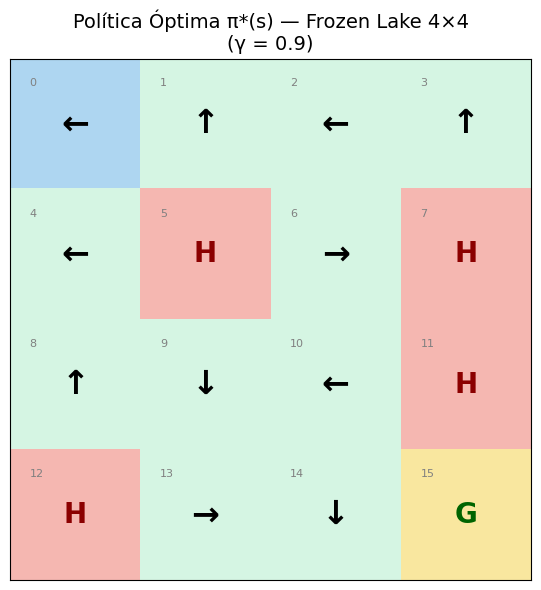

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# Crear grid de colores según tipo de celda
color_map = {"S": "#AED6F1", "F": "#D5F5E3", "H": "#F5B7B1", "G": "#F9E79F"}
grid_colors = np.zeros((mdp.n_rows, mdp.n_cols, 3))

for r in range(mdp.n_rows):
    for c in range(mdp.n_cols):
        s = mdp._rc_to_state(r, c)
        hex_color = color_map[mdp.cell_type[s]]
        rgb = mcolors.hex2color(hex_color)
        grid_colors[r, c] = rgb

ax.imshow(grid_colors, interpolation='nearest')

# Flechas Unicode y etiquetas
arrow_map = {0: "↑", 1: "↓", 2: "→", 3: "←"}

for r in range(mdp.n_rows):
    for c in range(mdp.n_cols):
        s = mdp._rc_to_state(r, c)
        if s in mdp.hole_states:
            label = "H"
            color = "darkred"
            fontsize = 20
        elif s in mdp.goal_states:
            label = "G"
            color = "darkgreen"
            fontsize = 20
        else:
            label = arrow_map[pi_star[s]]
            color = "black"
            fontsize = 24

        ax.text(c, r, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=color)
        # Número de estado (esquina superior izquierda)
        ax.text(c - 0.35, r - 0.35, str(s), ha='left', va='top',
                fontsize=8, color='gray')

ax.set_xticks(np.arange(-0.5, mdp.n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, mdp.n_rows, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=2)
ax.tick_params(which='both', bottom=False, left=False,
               labelbottom=False, labelleft=False)
ax.set_title(f"Política Óptima π*(s) — Frozen Lake 4×4\n(γ = {GAMMA})", fontsize=14)

plt.tight_layout()
plt.show()

#### b) Mapa de Calor de los valores V*(s) finales

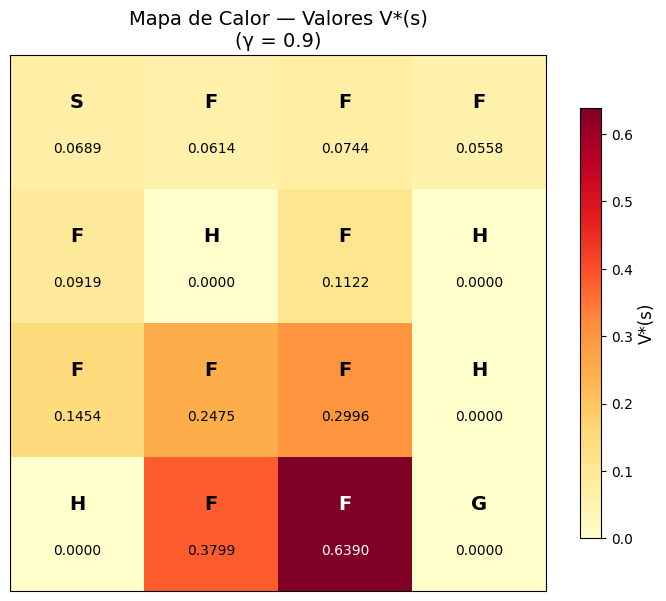

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

V_grid = V_star.reshape(mdp.n_rows, mdp.n_cols)

# Mapa de calor
im = ax.imshow(V_grid, cmap='YlOrRd', interpolation='nearest')
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('V*(s)', fontsize=12)

# Anotar cada celda con el valor y tipo
for r in range(mdp.n_rows):
    for c in range(mdp.n_cols):
        s = mdp._rc_to_state(r, c)
        cell_label = mdp.cell_type[s]
        val = V_star[s]

        # Color del texto según el valor (para legibilidad)
        text_color = 'white' if val > V_star.max() * 0.6 else 'black'

        ax.text(c, r - 0.15, cell_label, ha='center', va='center',
                fontsize=14, fontweight='bold', color=text_color)
        ax.text(c, r + 0.2, f"{val:.4f}", ha='center', va='center',
                fontsize=10, color=text_color)

ax.set_xticks(np.arange(-0.5, mdp.n_cols, 1), minor=True)
ax.set_yticks(np.arange(-0.5, mdp.n_rows, 1), minor=True)
ax.grid(which='minor', color='black', linewidth=2)
ax.tick_params(which='both', bottom=False, left=False,
               labelbottom=False, labelleft=False)
ax.set_title(f"Mapa de Calor — Valores V*(s)\n(γ = {GAMMA})", fontsize=14)

plt.tight_layout()
plt.show()

### Curva de convergencia

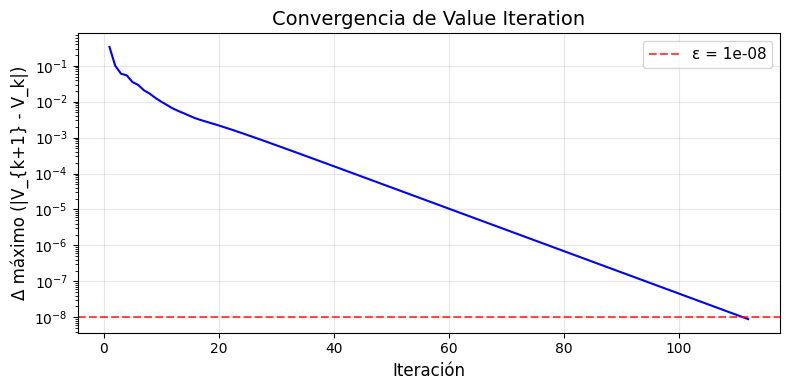

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(convergence_history) + 1), convergence_history, 'b-', linewidth=1.5)
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('Δ máximo (|V_{k+1} - V_k|)', fontsize=12)
ax.set_title('Convergencia de Value Iteration', fontsize=14)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.axhline(y=EPSILON, color='r', linestyle='--', alpha=0.7, label=f'ε = {EPSILON}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Análisis de resultados

#### ¿Qué celdas son las más valiosas?

Las celdas con mayor valor $V^*(s)$ son aquellas más cercanas al **Goal (G)** y que tienen caminos seguros para llegar a él. Debido a la estocasticidad del hielo (1/3 de ir a donde se desea y 2/3 de deslizarse a los lados), las celdas que están rodeadas de caminos seguros y cerca de la meta tienen valores más altos.

- Los **estados terminales** (H y G) tienen valor 0 porque son absorbentes (no se generan recompensas futuras desde ellos).
- Las celdas **adyacentes al Goal** (como el estado 14) tienen los valores más altos, ya que tienen la mayor probabilidad de alcanzar la recompensa +1.
- Las celdas **lejanas al Goal** o **rodeadas de agujeros** tienen valores bajos, reflejando la baja probabilidad de éxito.
- La **política óptima** guía al agente hacia el Goal evitando las direcciones que podrían llevarlo a caer en un agujero debido al deslizamiento del hielo.